<a href="https://colab.research.google.com/github/Yavanni/sputterSim_PHYS89_Sp2026/blob/main/GC_sputterSim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install numpy

In [ ]:
!pip install py3Dmol

In [ ]:
!pip install -q condacolab
import condacolab
condacolab.install()


⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:10
🔁 Restarting kernel...


In [ ]:
!mamba install -c conda-forge openmm



Looking for: ['openmm']

[+] 0.0s
[+] 0.1s
conda-forge/linux-64  ⣾  
conda-forge/noarch    ⣾  [+] 0.2s
conda-forge/linux-64   4%
conda-forge/noarch     6%[+] 0.3s
conda-forge/linux-64  12%
conda-forge/noarch    25%[+] 0.4s
conda-forge/linux-64  19%
conda-forge/noarch    38%[+] 0.5s
conda-forge/linux-64  22%
conda-forge/noarch    44%[+] 0.6s
conda-forge/linux-64  27%
conda-forge/noarch    54%[+] 0.7s
conda-forge/linux-64  33%
conda-forge/noarch    68%[+] 0.8s
conda-forge/linux-64  40%
conda-forge/noarch    81%[+] 0.9s
conda-forge/linux-64  47%
conda-forge/noarch    89%conda-forge/noarch                                
[+] 1.0s
conda-forge/linux-64  50%[+] 1.1s
conda-forge/linux-64  50%[+] 1.2s
conda-forge/linux-64  50%[+] 1.3s
conda-forge/linux-64  50%[+] 1.4s
conda-forge/linux-64  50%[+] 1.5s
conda-forge/linux-64  50%[+] 1.6s
conda-forge/linux-64  50%[+] 1.7s
conda-forge/linux-64  50%[+] 1.8s
conda-forge/linux-64  50%[+] 1.9s
conda-forge/linux-64  51%[+] 2.0s
conda-forge/linux-64  51%

In [ ]:
!conda install python=3.12
!mamba install -c conda-forge openmm


Channels:
 - conda-forge
Platform: linux-64
Solving environment: - \ | done

## Package Plan ##

  environment location: /usr/local

  added / updated specs:
    - python=3.12


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    brotli-python-1.2.0        |  py312hdb49522_1         360 KB  conda-forge
    c-ares-1.34.6              |       hb03c661_0         203 KB  conda-forge
    ca-certificates-2026.2.25  |       hbd8a1cb_0         144 KB  conda-forge
    certifi-2026.2.25          |     pyhd8ed1ab_0         148 KB  conda-forge
    cffi-2.0.0                 |  py312h460c074_1         289 KB  conda-forge
    conda-26.3.2               |  py312h7900ff3_0         1.2 MB  conda-forge
    conda-libmamba-solver-26.3.0|     pyhd8ed1ab_0          58 KB  conda-forge
    cpp-expected-1.3.1         |       h171cf75_0          24 KB  conda-forge
    fmt-12.1.0                 |       hff5e90c

In [ ]:
!pip install openmm


In [ ]:
!pip install py3Dmol

  Using cached py3dmol-2.5.4-py2.py3-none-any.whl.metadata (2.1 kB)
Using cached py3dmol-2.5.4-py2.py3-none-any.whl (7.2 kB)


In [ ]:
!pip install matplotlib

In [ ]:
# Standard imports
import sys
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.animation as animation
from mpl_toolkits.mplot3d import Axes3D

# OpenMM imports
from openmm.app import *
from openmm import *
from openmm.unit import *

In [ ]:
#Gas Phase Portion

# we initialize the random generator with a seed, so we can reproduce results and debug
seed_value = 12345
np.random.seed(seed_value)

# set the radius of the disks, all have the same radius:
r = 2.0

# set the dimensions of the rectangle
a = 100.0
b = 100.0
c = 100.0

# set the number of disks
n = 40

# set the number of dimensions
d = 3

# define an array of velocities
v = np.empty((n, d))

# define an array of positions (of the centers of the disks)
x = np.empty((n, d))

In [ ]:
def set_initial_positions(x):
    placed = 0
    max_attempts = 10000
    attempts = 0

    while placed < n and attempts < max_attempts:
        # Random candidate position, fully within bounds
        candidate = np.random.uniform(low=[r, r, r], high=[a - r, b - r, c - r])

        # Check distance from all previously placed particles
        if placed == 0:
            # No need to check on first particle
            x[placed] = candidate
            placed += 1
        else:
            distances = np.linalg.norm(x[:placed] - candidate, axis=1)
            if np.all(distances >= 2 * r):  # No overlaps
                x[placed] = candidate
                placed += 1

        attempts += 1

    if placed < n:
        raise RuntimeError(f"Only placed {placed} particles after {attempts} attempts. "
                           f"Try increasing box size or decreasing particle count.")

set_initial_positions(x)

for i, pos in enumerate(x):
    print(f"Particle {i+1}: x = {pos[0]:.2f}, y = {pos[1]:.2f}, z = {pos[2]:.2f}")

In [ ]:
def set_initial_velocities(v):
    #  we take the same speed for all disks, but a random angle
    speed = 1.0
    theta_angle = np.random.uniform(0, 2 * np.pi, size=n)
    phi_angle = np.arccos(np.random.uniform(-1, 1, size=n))

    # Note: The original 3D velocity generation `v_z = speed * np.sin(angle)`
    # is not a standard way to generate random 3D directions with a fixed speed.
    # For a truly random 3D direction, you might want to generate points
    # on a unit sphere (e.g., using spherical coordinates with two angles
    # or by normalizing random Cartesian components).
    # Keeping the original logic for now as the request is to fix the error.
    for i, (theta, phi) in enumerate(zip(theta_angle, phi_angle)):
        v_x = speed * np.cos(theta) * np.sin(phi)
        v_y = speed * np.sin(theta) * np.sin(phi)
        # This assumes v_z is dependent on the same angle as v_y, which might not be intended for 3D.
        v_z = speed * np.cos(phi)
        v[i] = [v_x, v_y, v_z]

# Ensure 'v' is defined by running the preceding cell (where v = np.empty((n, d)))
# before executing this cell.
v = np.empty((n, d))
set_initial_velocities(v)


# Corrected printing loop: iterate directly over the 'v' array
# where each element 'velocity_vector' is a particle's velocity.
for i, velocity_vector in enumerate(v):
    v_x, v_y, v_z = velocity_vector
    print(f"Particle {i+1}: velocity components = {v_x:.2f}, {v_y:.2f}, {v_z:.2f}")

In [ ]:
# find the first collision among the particles
# returns: time,i,j,wall_index
# wall_index is defined as follows.
# -1 if the first collision is between two disks,
# 0 - left wall
# 1 - right wall
# 2 - bottom wall
# 3 - top wall.
# Also, j=-1 if the first collision is with a wall. In that case "i" is the particle that collided with the wall.

#new notes:
# 4 - out of page wall
# 5 - into page wall
def time_to_earliest_collision(x,v,z):
    # WRITE YOUR CODE HERE
    earliest_time = float('inf')
    collision_i = -1
    collision_j = -1
    wall_index = -1

    for i in range(n):
        xi, yi, zi = x[i]
        vxi, vyi, vzi = v[i]

        if vxi < 0:
            coll_t = (r - xi) / vxi
            if 0 < coll_t < earliest_time:
                earliest_time = coll_t
                collision_i = i
                collision_j = -1
                wall_index = 0

        if vxi > 0:
            coll_t = (a - r - xi) / vxi
            if 0 < coll_t < earliest_time:
                earliest_time = coll_t
                collision_i = i
                collision_j = -1
                wall_index = 1

        if vyi < 0:
            coll_t = (r - yi) / vyi
            if 0 < coll_t < earliest_time:
                earliest_time = coll_t
                collision_i = i
                collision_j = -1
                wall_index = 2

        if vyi > 0:
            coll_t = (b - r - yi) / vyi
            if 0 < coll_t < earliest_time:
                earliest_time = coll_t
                collision_i = i
                collision_j = -1
                wall_index = 3

    for i in range(n):
        for j in range(i + 1, n):
            dx = x[j] - x[i]
            dv = v[j] - v[i]

            dv_dot_dx = np.dot(dv, dx)
            if dv_dot_dx >= 0:
                continue

            dv2 = np.dot(dv, dv)
            dx2 = np.dot(dx, dx)
            sigma = 2 * r

            discriminant = dv_dot_dx**2 - dv2 * (dx2 - sigma**2)
            if discriminant < 0:
                continue

            coll_t = -(dv_dot_dx + np.sqrt(discriminant)) / dv2
            if 0 < coll_t < earliest_time:
                earliest_time = coll_t
                collision_i = i
                collision_j = j
                wall_index = -1

    return earliest_time, collision_i, collision_j, wall_index

set_initial_positions(x)
set_initial_velocities(v)

coll_t, i, j, wall_index = time_to_earliest_collision(x, v)

print(f"First collision at time t = {coll_t:.4f}")
if wall_index == -1:
    print(f"Particle-particle collision between particle {i} and particle {j}")
else:
    print(f"Particle {i} collided with wall {wall_index}")

Setting up OpenMM simulation...
Minimizing energy to get a stable starting configuration...
Running simulation and collecting frames for animation...
Simulation finished! Creating animation...


KeyboardInterrupt: 

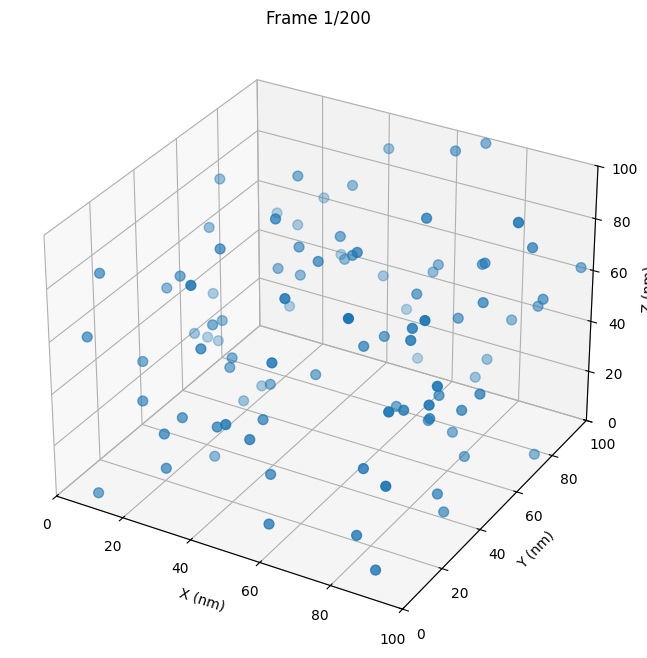

In [ ]:
print("Setting up OpenMM simulation...")

## Make sure imports have run before running this cell.

# 1. Define system parameters
num_particles = 100
box_size = 100.0 * nanometers # Runs even with these undefined vars, b/c units defined in OpenMM?
particle_radius = 0.17 * nanometers # KINETIC radius of an Argon particle
temperature = 1000 * kelvin  # Common temperature for MD simulations (200-500K)
collision_rate = 1.0 / picosecond  # Controls coupling to heat bath for Langevin integrator ## CHANGE TO VERLET?
step_size = 2.0 * femtoseconds # Typical timestep for MD

# Lennard-Jones parameters (sigma and epsilon)
sigma = 2.0 * particle_radius
epsilon = 1.0 * kilojoule_per_mole

# 2. Create an OpenMM System
system = System()
for i in range(num_particles):
    system.addParticle(39.948 * amu)

# 3. Add a NonbondedForce (Lennard-Jones potential)
lj_force = NonbondedForce()
for i in range(num_particles):
    lj_force.addParticle(0.0, sigma, epsilon)

lj_force.setCutoffDistance(3 * sigma)
lj_force.setNonbondedMethod(NonbondedForce.CutoffPeriodic)

system.setDefaultPeriodicBoxVectors(
    Vec3(box_size, 0, 0),
    Vec3(0, box_size, 0),
    Vec3(0, 0, box_size)
)
system.addForce(lj_force)

# 4. Set up an Integrator (LangevinIntegrator for NVT ensemble) # SWITCH TO VERLET?
integrator = LangevinIntegrator(temperature, collision_rate, step_size)

# 5. Set up the Platform (choose 'CPU', 'CUDA', or 'OpenCL')
platform = Platform.getPlatformByName('CPU')

# 6. Create a Simulation object
simulation = Simulation(None, system, integrator, platform)

# 7. Initialize positions (simple random placement within the box)
positions = []
for i in range(num_particles):
    pos_x = np.random.uniform(0, box_size._value)
    pos_y = np.random.uniform(0, box_size._value)
    pos_z = np.random.uniform(0, box_size._value)
    positions.append(Vec3(pos_x, pos_y, pos_z))
simulation.context.setPositions(positions)

# 8. Initialize velocities from a Maxwell-Boltzmann distribution at the given temperature
simulation.context.setVelocitiesToTemperature(temperature) ## CHANGE ?

# 9. Add Reporters for output (optional, but good for saving data)
# simulation.reporters.append(PDBReporter('trajectory.pdb', 100)) # Save positions every 100 steps
# simulation.reporters.append(StateDataReporter('log.txt', 1000, step=True,
# potentialEnergy=True, kineticEnergy=True, totalEnergy=True, temperature=True))

# 10. Run the simulation and collect positions for animation
print("Minimizing energy to get a stable starting configuration...")
simulation.minimizeEnergy()

print("Running simulation and collecting frames for animation...")

# Parameters for animation
total_simulation_steps = 10000 # Reduced for quicker demo, increase for longer simulation
num_frames = 200
steps_per_frame = total_simulation_steps // num_frames

all_positions = []
for i in range(num_frames):
    simulation.step(steps_per_frame)
    state = simulation.context.getState(getPositions=True)
    all_positions.append(state.getPositions(asNumpy=True))

print("Simulation finished! Creating animation...")

# 11. Create and display the animation
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

def update(frame):
    ax.clear()
    ax.scatter(all_positions[frame][:,0], all_positions[frame][:,1], all_positions[frame][:,2], s=50)
    ax.set_title(f'Frame {frame+1}/{num_frames}')
    ax.set_xlabel('X (nm)')
    ax.set_ylabel('Y (nm)')
    ax.set_zlabel('Z (nm)')
    ax.set_xlim(0, box_size._value)
    ax.set_ylim(0, box_size._value)
    ax.set_zlim(0, box_size._value)

ani = animation.FuncAnimation(fig, update, frames=num_frames, interval=50, blit=False)

# To display the animation in Colab, we need to convert it to an HTML5 video.
# This might take a moment depending on the number of frames.
from IPython.display import HTML
HTML(ani.to_jshtml())


To do:
- fix velocities, particle parameters? currently, sim works, but particles are not moving very much like we expect from a gas, how to fix?
- implement real vacuum chamber size via paper (rectangular box)
- implement magnetron + substrate SOMEHOW, darn you pySIMTRA for not working on linux!!
- probably shamelessly ripping code if we can from pySIMTRA
- OpenMM does have trackers implemented so we can track velocities, positions, I think
- units sanity check?